In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import butter, filtfilt
from pyedflib import EdfReader
from pathlib import Path
import os # Importar o módulo os para criar diretórios e gerenciar caminhos

# --- Funções de Processamento de Dados (Mantidas e Adaptadas) ---

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def notch_filter(data, notch_freq, fs, quality=30):
    nyquist = 0.5 * fs
    freq = notch_freq / nyquist
    b, a = butter(2, [freq - 0.5/quality, freq + 0.5/quality], btype='bandstop')
    return filtfilt(b, a, data)

def compute_individual_epoch_stft(data, events, event_type, tmin, tmax, fs,
                                  nperseg, noverlap, nfft):
    """
    Compute STFT for each individual epoch of a specific event type.
    Returns a list of dictionaries, each containing (f, t, Zxx) for an epoch.
    """
    event_samples = [e[0] for e in events if e[2] == event_type]
    
    individual_stft_data = []
    
    for i, sample in enumerate(event_samples):
        start = sample + int(tmin * fs)
        end = sample + int(tmax * fs)
        epoch = data[start:end]
        
        # Check if epoch is valid (not empty)
        if len(epoch) == 0:
            print(f"    Warning: Epoch {i+1} for {event_type} is empty. Skipping.")
            continue

        # Ensure epoch is long enough for the STFT window
        if len(epoch) < nperseg:
            print(f"    Warning: Epoch {i+1} for {event_type} (length {len(epoch)}) is shorter than nperseg ({nperseg}). Skipping STFT for this epoch.")
            continue

        f, t, Zxx = signal.stft(epoch, fs=fs, window='hann',
                               nperseg=nperseg, noverlap=noverlap, nfft=nfft)
        individual_stft_data.append({'epoch_idx': i, 'frequencies': f, 'times': t, 'magnitude': np.abs(Zxx)})
        
    return individual_stft_data

# --- Configurações Globais ---

# Pasta contendo os arquivos EDF (ajuste conforme necessário)
# Exemplo: Se seus arquivos estão em 'seu_projeto/data/phisionet_data/S001/'
# E o script está em 'seu_projeto/'
pasta_base_dados = Path('data/phisionet_data/S001') 
registros = ['R04', 'R08', 'R12'] # Arquivos EDF a serem processados
event_dict = {'T0': 'rest', 'T1': 'left', 'T2': 'right'} # Mapeamento para nomes de pastas em minúsculas
epoch_duration_sec = 4 # Duração de cada época em segundos (tmax - tmin)

# Definir a taxa de amostragem globalmente (ASSUMIR UM VALOR OU LER DO PRIMEIRO ARQUIVO)
# Por exemplo, se a taxa de amostragem dos seus arquivos é 160 Hz:
fs = 160 # <--- ADICIONAR ESTA LINHA COM A SUA TAXA DE AMOSTRAGEM

# Definir as durações de janela da STFT a serem testadas (em milissegundos)
window_durations_ms = [50, 100, 200, 400, 600, 800, 1000]
window_durations_sec = [ms / 1000.0 for ms in window_durations_ms]

# --- Loop Principal para Processamento ---

print("Iniciando o processamento de espectrogramas para múltiplos arquivos e janelas...")

# Loop sobre cada duração de janela da STFT
for i, window_duration_s in enumerate(window_durations_sec):
    current_window_ms = window_durations_ms[i]
    
    # Recalcular parâmetros da STFT para a duração de janela atual
    nperseg = int(fs * window_duration_s)
    # noverlap deve ser menor que nperseg e pode ser 75% para boa resolução temporal
    noverlap = int(nperseg * 0.75)
    nfft = nperseg * 2 # Zero padding

    # Garante que nperseg e noverlap sejam pelo menos 1 e noverlap < nperseg
    nperseg = max(1, nperseg)
    noverlap = min(noverlap, nperseg - 1)
    if nperseg == 1: # Caso nperseg seja 1, noverlap deve ser 0
        noverlap = 0

    print(f"\n--- Processando com Janela de {current_window_ms}ms (nperseg={nperseg}, noverlap={noverlap}) ---")

    # Diretório base para a duração da janela atual (ex: 'spectrograms_50ms')
    base_output_dir_window = f"spectrograms_{current_window_ms}ms"
    os.makedirs(base_output_dir_window, exist_ok=True)

    # Loop sobre cada arquivo EDF
    for registro in registros:
        # Encontrar arquivo .edf correspondente
        edf_file = next(pasta_base_dados.glob(f'*{registro}.edf'), None)
        if not edf_file:
            print(f"    Arquivo {registro}.edf não encontrado em {pasta_base_dados}. Pulando.")
            continue

        print(f"    Processando arquivo: {edf_file.name}")
        
        # Diretório para o arquivo EDF atual dentro da pasta da janela (ex: 'spectrograms_50ms/S001R04')
        file_output_dir = os.path.join(base_output_dir_window, edf_file.stem.replace('.', '_')) # Remove '.edf' e substitui '.' por '_'
        os.makedirs(file_output_dir, exist_ok=True)

        # Carregar dados EDF usando EdfReader
        reader = EdfReader(str(edf_file))
        
        # Obter informações dos sinais
        n_channels = reader.signals_in_file
        signal_labels = reader.getSignalLabels()
        # fs = reader.getSampleFrequency(0) # ESTA LINHA AGORA PODE SER REMOVIDA OU MANTEVE-A PARA ATUALIZAR FS SE PRECISAR
                                          # MAS A DEFINIÇÃO GLOBAL DEVE SER A PRIMEIRA
        signals_data = np.array([reader.readSignal(c) for c in range(n_channels)])
        
        # Obter canais C3 e C4
        try:
            c3_idx = signal_labels.index('C3..')
            c4_idx = signal_labels.index('C4..')
        except ValueError:
            print(f"    Canais 'C3..' ou 'C4..' não encontrados em {edf_file.name}. Pulando este arquivo.")
            reader.close()
            continue

        c3_signal = signals_data[c3_idx, :]
        c4_signal = signals_data[c4_idx, :]
        
        # Ler anotações diretamente do arquivo EDF
        annotations_onset, annotations_duration, annotations_description = reader.readAnnotations()
        reader.close() # Fechar o reader após ler tudo

        # Converter anotações para formato de eventos (amostras em vez de segundos)
        events = []
        for onset, duration, description in zip(annotations_onset, annotations_duration, annotations_description):
            events.append([int(onset * fs), 0, description])
        
        # Aplicar filtros
        c3_filtered = notch_filter(bandpass_filter(c3_signal, 0.5, 40, fs), 50, fs)
        c4_filtered = notch_filter(bandpass_filter(c4_signal, 0.5, 40, fs), 50, fs)
        
        # Processar condições (T0, T1, T2)
        conditions = ['T0', 'T1', 'T2']
        all_epoch_stfts_for_file = {} # Armazena STFTs para o arquivo atual

        for cond_key in conditions:
            print(f"    Calculando STFT para {event_dict[cond_key].capitalize()}...")
            c3_epoch_data = compute_individual_epoch_stft(c3_filtered, events, cond_key, tmin=0, tmax=epoch_duration_sec, fs=fs,
                                                           nperseg=nperseg, noverlap=noverlap, nfft=nfft)
            c4_epoch_data = compute_individual_epoch_stft(c4_filtered, events, cond_key, tmin=0, tmax=epoch_duration_sec, fs=fs,
                                                           nperseg=nperseg, noverlap=noverlap, nfft=nfft)
            
            all_epoch_stfts_for_file[cond_key] = {'C3': c3_epoch_data, 'C4': c4_epoch_data}

        # Visualization and Saving
        for cond_key in conditions:
            c3_data = all_epoch_stfts_for_file[cond_key]['C3']
            c4_data = all_epoch_stfts_for_file[cond_key]['C4']

            # Criar a subpasta para o tipo de evento (ex: 'rest', 'left', 'right')
            event_type_dir = os.path.join(file_output_dir, event_dict[cond_key])
            os.makedirs(event_type_dir, exist_ok=True)
            print(f"    Salvando espectrogramas em: {event_type_dir}")

            # Iterar sobre cada época individual para plotar e salvar
            for j in range(len(c3_data)): # Assume que C3 e C4 têm o mesmo número de épocas
                epoch_idx = c3_data[j]['epoch_idx']
                f_c3, t_c3, Zxx_c3 = c3_data[j]['frequencies'], c3_data[j]['times'], c3_data[j]['magnitude']
                f_c4, t_c4, Zxx_c4 = c4_data[j]['frequencies'], c4_data[j]['times'], c4_data[j]['magnitude']

                # --- NOVO: Salvar os dados numéricos do espectrograma como .npy ---
                # Nome base do arquivo para esta época
                base_filename = f"epoch_{epoch_idx+1}"
                
                # Caminho completo para salvar o arquivo .npy C3
                npy_c3_path = os.path.join(event_type_dir, f"{base_filename}_C3.npy")
                np.save(npy_c3_path, Zxx_c3)

                # Caminho completo para salvar o arquivo .npy C4
                npy_c4_path = os.path.join(event_type_dir, f"{base_filename}_C4.npy")
                np.save(npy_c4_path, Zxx_c4)
                # --- FIM DO NOVO CÓDIGO ---

                # (Opcional: Manter o salvamento do PNG se desejar visualizar os espectrogramas)
                fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

                # Plot C3
                im1 = axes[0].pcolormesh(t_c3, f_c3, Zxx_c3, shading='gouraud', vmin=0, vmax=np.percentile(Zxx_c3, 95))
                fig.colorbar(im1, ax=axes[0], label='Magnitude')
                axes[0].set_title(f'{event_dict[cond_key].capitalize()} - Época {epoch_idx+1} - C3')
                axes[0].set_ylabel('Frequência [Hz]')
                axes[0].set_xlabel('Tempo [s]')
                axes[0].set_ylim([8, 30])
                
                # Plot C4
                im2 = axes[1].pcolormesh(t_c4, f_c4, Zxx_c4, shading='gouraud', vmin=0, vmax=np.percentile(Zxx_c4, 95))
                fig.colorbar(im2, ax=axes[1], label='Magnitude')
                axes[1].set_title(f'{event_dict[cond_key].capitalize()} - Época {epoch_idx+1} - C4')
                axes[1].set_xlabel('Tempo [s]')
                axes[1].set_ylim([8, 30])

                plt.tight_layout()
                
                # Salvar o espectrograma como PNG (opcional)
                png_path = os.path.join(event_type_dir, f"{base_filename}.png")
                plt.savefig(png_path)
                plt.close(fig)

print(f"\nProcessamento concluído. Todos os espectrogramas foram salvos na estrutura de diretórios especificada.")

Iniciando o processamento de espectrogramas para múltiplos arquivos e janelas...

--- Processando com Janela de 50ms (nperseg=8, noverlap=6) ---
    Processando arquivo: S001R04.edf
    Calculando STFT para Rest...
    Calculando STFT para Left...
    Calculando STFT para Right...
    Salvando espectrogramas em: spectrograms_50ms\S001R04\rest
    Salvando espectrogramas em: spectrograms_50ms\S001R04\left
    Salvando espectrogramas em: spectrograms_50ms\S001R04\right
    Processando arquivo: S001R08.edf
    Calculando STFT para Rest...
    Calculando STFT para Left...
    Calculando STFT para Right...
    Salvando espectrogramas em: spectrograms_50ms\S001R08\rest
    Salvando espectrogramas em: spectrograms_50ms\S001R08\left
    Salvando espectrogramas em: spectrograms_50ms\S001R08\right
    Processando arquivo: S001R12.edf
    Calculando STFT para Rest...
    Calculando STFT para Left...
    Calculando STFT para Right...
    Salvando espectrogramas em: spectrograms_50ms\S001R12\rest
 

In [4]:
import numpy as np
sample_spectrogram = np.load(r's0-50\unified_spectrograms_100ms\left\S001_S001R04_epoch_1_C4.npy')
print(sample_spectrogram.shape) # Isso te dará (altura, largura)

(17, 161)


Assumindo IMG_HEIGHT=33 e IMG_WIDTH=81. Verifique se isso está correto.

--- Treinando o modelo para dados numéricos em spectrograms_200ms ---
Attempting to read from root directory: spectrograms_200ms
  Checking EDF file directory: spectrograms_200ms\S001R04
    Checking class directory: spectrograms_200ms\S001R04\rest
    Checking class directory: spectrograms_200ms\S001R04\left
    Checking class directory: spectrograms_200ms\S001R04\right
  Skipping non-directory item in data_root_dir: spectrograms_200ms\S001R04
  Checking EDF file directory: spectrograms_200ms\S001R08
    Checking class directory: spectrograms_200ms\S001R08\rest
    Checking class directory: spectrograms_200ms\S001R08\left
    Checking class directory: spectrograms_200ms\S001R08\right
  Skipping non-directory item in data_root_dir: spectrograms_200ms\S001R08
  Checking EDF file directory: spectrograms_200ms\S001R12
    Checking class directory: spectrograms_200ms\S001R12\rest
    Checking class directory: spectrog

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 31, 79, 32)     │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 39, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 18, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 16, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,619 (1.36 MB)

 Trainable params: 355,619 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.3398 - loss: 1.0945 - val_accuracy: 0.6111 - val_loss: 0.9787
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4774 - loss: 1.0593 - val_accuracy: 0.7222 - val_loss: 0.8620
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5569 - loss: 0.9755 - val_accuracy: 0.4444 - val_loss: 1.1347
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5382 - loss: 1.0120 - val_accuracy: 0.6111 - val_loss: 0.9816
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4766 - loss: 1.0954 - val_accuracy: 0.4444 - val_loss: 1.0784
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4431 - loss: 1.0884 - val_accuracy: 0.5000 - val_loss: 1.0724
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5165 - loss: 1.0653 - val_accuracy: 0.4444 - val_loss: 1.0796
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4501 - loss: 1.0725 - val_accuracy: 0.5556 - val_loss:

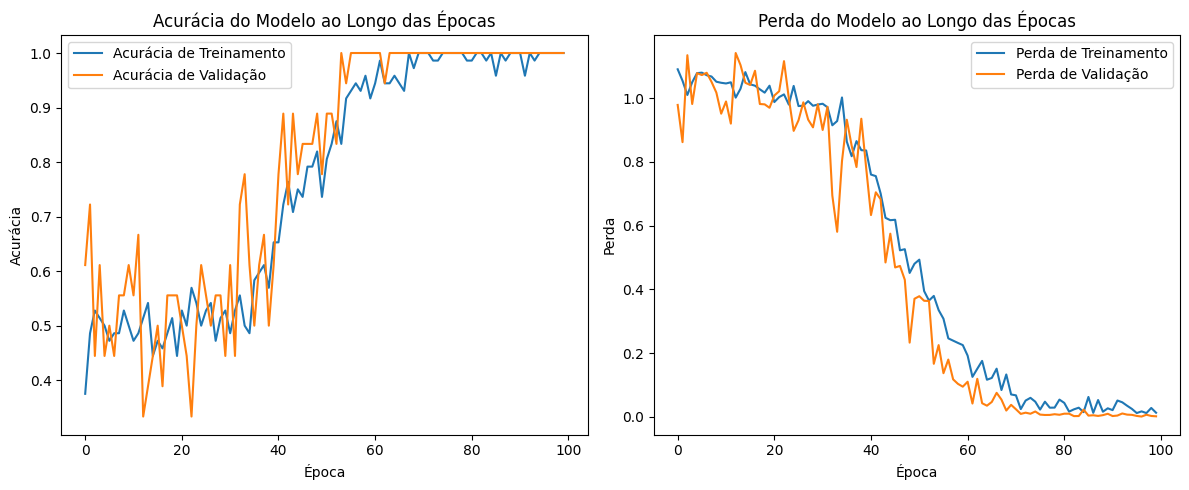

In [12]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import os
import matplotlib.pyplot as plt # Adicionado para a plotagem no __main__

# --- Parâmetros de Configuração ---
# Estas dimensões devem corresponder à saída da sua STFT.
# Calcule-as inspecionando um Zxx.shape de um espectrograma salvo.
# Exemplo: Se f tiver 23 pontos e t tiver 29 pontos:
IMG_HEIGHT = 33 # Número de bins de frequência (rows de Zxx) - Verifique com seus dados reais!
IMG_WIDTH = 81 # Número de bins de tempo (columns de Zxx) - Verifique com seus dados reais!
NUM_CLASSES = 3 # 'rest', 'left', 'right'
BATCH_SIZE = 32
EPOCHS = 100

# Mapeamento de rótulos para inteiros
label_map = {'rest': 0, 'left': 1, 'right': 2}

# Caminho para o diretório raiz dos seus espectrogramas (ex: spectrograms_200ms)
DATA_ROOT_DIR = 'spectrograms_200ms' # Mude isso para a pasta de interesse

# --- Função para carregar e pré-processar um único espectrograma (agora .npy) ---
def load_spectrogram_data(filepath_c3, filepath_c4, label):
    # Carrega os arrays NumPy
    spectrogram_c3 = np.load(filepath_c3).astype(np.float32)
    spectrogram_c4 = np.load(filepath_c4).astype(np.float32)

    # Normalização: Importante!
    # Normalize cada espectrograma individualmente ou por batch, dependendo da sua estratégia.
    # Normalização min-max para 0-1 (garantindo que não dividimos por zero se for tudo 0)
    min_c3, max_c3 = np.min(spectrogram_c3), np.max(spectrogram_c3)
    spectrogram_c3 = (spectrogram_c3 - min_c3) / (max_c3 - min_c3 + 1e-8) if (max_c3 - min_c3) > 1e-8 else spectrogram_c3

    min_c4, max_c4 = np.min(spectrogram_c4), np.max(spectrogram_c4)
    spectrogram_c4 = (spectrogram_c4 - min_c4) / (max_c4 - min_c4 + 1e-8) if (max_c4 - min_c4) > 1e-8 else spectrogram_c4

    # Adiciona a dimensão do canal e concatena C3 e C4
    # Resulta em um array de shape (IMG_HEIGHT, IMG_WIDTH, 2)
    combined_spectrogram = np.stack([spectrogram_c3, spectrogram_c4], axis=-1)
    
    return combined_spectrogram, label

# --- Criar o dataset (AJUSTADO PARA A NOVA ESTRUTURA) ---
def create_dataset_from_directories_npy(data_root_dir):
    all_filepaths_c3 = []
    all_filepaths_c4 = []
    all_labels = []

    print(f"Attempting to read from root directory: {data_root_dir}")
    if not os.path.exists(data_root_dir):
        print(f"Error: Data root directory does not exist: {data_root_dir}")
        return None, None
            
    # Iterar sobre as pastas de cada arquivo EDF (S001R04, S001R08, etc.)
    for edf_file_dir_name in os.listdir(data_root_dir):
        full_edf_path = os.path.join(data_root_dir, edf_file_dir_name)
        print(f"  Checking EDF file directory: {full_edf_path}")
        if os.path.isdir(full_edf_path):
            # Iterar sobre as subpastas de classes (left, right, rest) dentro de cada pasta EDF
            for class_name in label_map.keys():
                class_dir = os.path.join(full_edf_path, class_name)
                print(f"    Checking class directory: {class_dir}")
                if not os.path.exists(class_dir):
                    print(f"    Warning: Class directory does not exist: {class_dir}. Skipping.")
                    continue 

                # Iterar sobre os arquivos .npy de espectrograma dentro da pasta da classe
                for img_filename in os.listdir(class_dir):
                    if img_filename.endswith('_C3.npy'):
                        filepath_c3 = os.path.join(class_dir, img_filename)
                        filepath_c4 = filepath_c3.replace('_C3.npy', '_C4.npy')
                        
                        if os.path.exists(filepath_c4): # Verifica se o C4 correspondente existe
                            all_filepaths_c3.append(filepath_c3)
                            all_filepaths_c4.append(filepath_c4)
                            all_labels.append(label_map[class_name])
                            # print(f"      Found pair: {filepath_c3} and {filepath_c4}") # Uncomment for verbose
                        else:
                            print(f"      Warning: Missing C4 file for {filepath_c3}. Skipping.")
            else:
                print(f"  Skipping non-directory item in data_root_dir: {full_edf_path}")
    
    print(f"Total C3 files found: {len(all_filepaths_c3)}")
    print(f"Total C4 files found: {len(all_filepaths_c4)}")
    print(f"Total labels found: {len(all_labels)}")

    # Converte para tensores TensorFlow
    filepaths_c3_tensor = tf.constant(all_filepaths_c3)
    filepaths_c4_tensor = tf.constant(all_filepaths_c4)
    labels_tensor = tf.constant(all_labels)

    # Cria o dataset TensorFlow
    dataset = tf.data.Dataset.from_tensor_slices(((filepaths_c3_tensor, filepaths_c4_tensor), labels_tensor))
    dataset = dataset.map(lambda x, y: tf.numpy_function(load_spectrogram_data, [x[0], x[1], y], (tf.float32, tf.int32)),
                          num_parallel_calls=tf.data.AUTOTUNE)
    
    # Define as formas dos tensores de saída da função numpy_function
    dataset = dataset.map(lambda spec, label: (tf.ensure_shape(spec, (IMG_HEIGHT, IMG_WIDTH, 2)), tf.ensure_shape(label, ())),
                          num_parallel_calls=tf.data.AUTOTUNE)

    # Divide em conjuntos de treinamento e validação (80/20)
    dataset_size = tf.data.experimental.cardinality(dataset).numpy()
    if dataset_size == 0:
        print("Erro: Dataset vazio. Não há dados para treinamento/validação.")
        return None, None
        
    train_size = int(0.8 * dataset_size)

    dataset = dataset.shuffle(buffer_size=dataset_size) # Embaralha o dataset
    train_ds = dataset.take(train_size)
    val_ds = dataset.skip(train_size)

    # Otimizações para desempenho
    train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    return train_ds, val_ds

# --- Definição do Modelo CNN (ajustado para 2 canais) ---
def create_cnn_model_npy(input_shape=(IMG_HEIGHT, IMG_WIDTH, 2), num_classes=NUM_CLASSES): # input_shape agora tem 2 canais
    model = models.Sequential()

    # Camada Convolucional 1
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D((2, 2)))

    # Camada Convolucional 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    # Camada Convolucional 3
    model.add(layers.Conv2D(128, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    # Achatar a saída das camadas convolucionais
    model.add(layers.Flatten())

    # Camadas Densas (Fully Connected)
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5)) # Dropout para evitar overfitting
    model.add(layers.Dense(num_classes, activation='softmax')) # Saída para classificação multiclasse

    # Compilar o modelo
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy', # Usar para labels inteiras
                  metrics=['accuracy'])
    
    return model

# --- Treinamento ---
if __name__ == '__main__':
    # Você pode iterar sobre window_durations_ms aqui se quiser treinar um modelo para cada
    # tamanho de janela, ou escolher um específico.
    
    # Exemplo: Treinando com os espectrogramas de 200ms
    current_window_ms = 200 # Escolha a duração da janela que você deseja treinar
    current_data_root_dir = f'spectrograms_{current_window_ms}ms' 

    # IMPORTANTE: Você precisa obter as dimensões corretas (IMG_HEIGHT, IMG_WIDTH) da sua STFT.
    # Uma forma fácil é rodar o script que gera os .npy e inspecionar o shape de um arquivo salvo:
    # Zxx_c3 = np.load('caminho_para_um_epoch_X_C3.npy')
    # IMG_HEIGHT, IMG_WIDTH = Zxx_c3.shape 
    # Use esses valores para definir IMG_HEIGHT e IMG_WIDTH acima.
    print(f"Assumindo IMG_HEIGHT={IMG_HEIGHT} e IMG_WIDTH={IMG_WIDTH}. Verifique se isso está correto.")
    
    print(f"\n--- Treinando o modelo para dados numéricos em {current_data_root_dir} ---")
    train_dataset, val_dataset = create_dataset_from_directories_npy(current_data_root_dir)

    if train_dataset is None or tf.data.experimental.cardinality(train_dataset).numpy() == 0:
        print(f"Não há dados de treinamento suficientes em {current_data_root_dir}. Treinamento abortado.")
    else:
        model = create_cnn_model_npy()
        model.summary()

        history = model.fit(train_dataset,
                            epochs=EPOCHS,
                            validation_data=val_dataset)

        # --- Avaliação e Visualização dos Resultados do Treinamento ---
        print("\n--- Avaliação Final do Modelo ---")
        loss, accuracy = model.evaluate(val_dataset)
        print(f"Acurácia no conjunto de validação: {accuracy*100:.2f}%")

        # Plotar histórico de treinamento
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.plot(history.history['accuracy'], label='Acurácia de Treinamento')
        plt.plot(history.history['val_accuracy'], label='Acurácia de Validação')
        plt.xlabel('Época')
        plt.ylabel('Acurácia')
        plt.legend()
        plt.title('Acurácia do Modelo ao Longo das Épocas')

        plt.subplot(1, 2, 2)
        plt.plot(history.history['loss'], label='Perda de Treinamento')
        plt.plot(history.history['val_loss'], label='Perda de Validação')
        plt.xlabel('Época')
        plt.ylabel('Perda')
        plt.legend()
        plt.title('Perda do Modelo ao Longo das Épocas')
        plt.tight_layout()
        plt.show()

        # Opcional: Salvar o modelo treinado
        # model.save(f'eeg_spectrogram_cnn_model_npy_{current_window_ms}ms.keras')
        # print(f"Modelo salvo como 'eeg_spectrogram_cnn_model_npy_{current_window_ms}ms.keras'")